# GWW: Calibration Using Satellite-derived Storage
***

**Author:** *Chus Casado Rodríguez*<br>
**Date:** *10-06-2026*<br>

**Introduction:**<br>

This notebook analyses the calibration of the reservoir routines using the reservoir storage estimates from Global Water Watch.

**Ideas:**<br>

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from pathlib import Path

import yaml
import pickle

from reservoirs_lshm import Config, read_attributes, read_timeseries, get_target_variable
from reservoirs_lshm.utils.plots import maps_performance, boxplot_parameters, boxplot_comparison, swarmplot_comparison
from reservoirs_lshm.utils.metrics import KGEmod, ECDF, PDE
from reservoirs_lshm.utils.utils import CDF, get_normal_value, return_period
from reservoirs_lshm.calibration import read_results
from utils import map_reservoirs, map_reservoirs_use

import warnings
warnings.filterwarnings("ignore")

/home/casadoj/Git/reservoirs-LSHM/src/reservoirs_lshm/utils/plots.py:1573: SyntaxWarning: invalid escape sequence '\s'
  """


In [ ]:
plt.rcParams.update({
#     "font.family": 'Arial',
    "font.size": 12,       # Default font size for text
#     "axes.titlesize": 16,  # Title font size
#     "axes.labelsize": 12,  # X and Y label font size
#     "xtick.labelsize": 13, # X tick font size
#     "ytick.labelsize": 12, # Y tick font size
#     "legend.fontsize": 12  # Legend font size
})

## Configuration

In [3]:
path = Path('/home/casadoj/Data/reservoirs')
cfg = Config(path / 'ResOpsUS/v2.3/results/config_mhm_gww.yml')

PATH_RESULTS = cfg.PATH_DEF.parent.parent
PATH_PLOTS = PATH_RESULTS / 'figures'
print(f'Results will be saved in {PATH_PLOTS}')

models = {
    'lisflood': 'LISFLOOD',
    'camaflood': 'CaMa-Flood',
    'mhm': 'mHM',
    'starfit': 'Starfit'
}

runs = {
    'default': 'default',
    'OBJ-V-GWW': 'calibration/univariate/storage_gww',
}

Results will be saved in /home/casadoj/Data/reservoirs/ResOpsUS/v2.3/results/figures


## Data

### Base layers

In [4]:
# load GloFAS' elevation and upstream area map
elevation = rxr.open_rasterio(cfg.PATH_DATA.parent / 'GIS' / 'elv_3min_US.tif', masked=True).squeeze('band')
uparea = rxr.open_rasterio(cfg.PATH_DATA.parent / 'GIS' / 'upArea_3min_US.tif', masked=True).squeeze('band')

### Reservoirs

In [5]:
# load reservoirs
# reservoirs = gpd.read_file(cfg.PATH_DATA.parent / 'ancillary' / 'lfcoords' / 'reservoirs_677_3sec.shp').set_index('ID')
reservoirs = gpd.read_file(cfg.PATH_DATA.parent / 'GIS' / 'reservoirs_677_3sec.shp').set_index('ID')
reservoirs.index.name = 'GRAND_ID'

print(f'{len(reservoirs)} reservoirs in the original ResOpsUS dataset')

677 reservoirs in the original ResOpsUS dataset


### Attributes

In [6]:
# list of reservoirs to be trained
reservoir_list = pd.read_csv(cfg.RESERVOIRS_FILE, header=None).squeeze().tolist()

# import all tables of attributes
attributes = read_attributes(cfg.PATH_DATA / 'attributes', reservoir_list)

# invert the one-hot encoder of main reservoir use
col_use = attributes.columns[attributes.columns.str.contains('MAIN_')]
col_use = [col for col in col_use if 'BASIN' not in col]
main_use = attributes[col_use].idxmax(axis=1)
attributes['MAIN_USE'] = main_use.replace({col: col.split('_')[-1] for col in col_use})
attributes.drop(col_use, axis=1, inplace=True)

# select items in reservoirs
reservoirs = reservoirs.loc[reservoirs.index.intersection(attributes.index)]

print(f'{len(attributes)} reservoirs in the attributes table')
print(f'{len(reservoirs)} reservoirs in the shape file')

12 reservoirs in the attributes table
12 reservoirs in the shape file


### Time series

I load the observed storage and outflow time series, not the GWW storage estimates. The purpose of this time series is to compute model performance agains the best estimate of reservoir operations, which is the in situ data.

In [7]:
# training periods
with open(cfg.PERIODS_FILE, 'rb') as file:
    periods = pickle.load(file)

# read time series
inputs = [var for var in [cfg.INFLOW, cfg.PRECIPITATION, cfg.EVAPORATION, cfg.DEMAND] if var]
outputs = ['storage', 'outflow']
timeseries = read_timeseries(
    path=cfg.PATH_DATA / 'time_series' / 'csv',
    reservoirs=attributes.index,
    periods=periods,
    variables=inputs + outputs
)
print(f'{len(timeseries)} reservoirs in the time series')

# compute 100-year return period of the inflow
Q100 = [return_period(ts.inflow, T=100) for grand_id, ts in timeseries.items()]
Q100 = xr.DataArray(data=Q100, coords=[list(timeseries)], dims=['ID'])

  0%|          | 0/12 [00:00<?, ?it/s]

12 reservoirs in the time series


## Performance

### GWW calibration

In [8]:
# parameters = {}
# performance = []
# for model in tqdm(models, desc='reservoir model'):

#     pars_model = []
#     perf_model = []
#     for run, subpath in runs.items():

#         path = PATH_RESULTS / model / subpath        

#         # load parameters
#         try:
#             pars_run = []
#             for file in path.glob('*_parameters.yml'):
#                 grand_id = int(file.stem.split('_')[0])
#                 if grand_id not in attributes.index:
#                     continue
#                 with open(file, 'r') as f:
#                      dct = yaml.load(f, Loader=yaml.FullLoader)
#                 ds = xr.Dataset({key: xr.DataArray(value) for key, value in dct.items()})
#                 ds = ds.assign_coords(ID=[grand_id], run=[run])
#                 pars_run.append(ds)
#             pars_model.append(xr.concat(pars_run, dim='ID'))
#         except Exception as e:
#             print(f'Error while reading parameters from model {model} and run {run}:\n{e}')          

#         # load performance
#         try:
#             perf_run = []
#             for file in (path).glob('*_performance.csv'):
#                 grand_id = int(file.stem.split('_')[0])
#                 if grand_id not in attributes.index:
#                     continue
#                 ds = xr.Dataset.from_dataframe(pd.read_csv(file, index_col='metric'))
#                 ds = ds.assign_coords(model=[model], run=[run], ID=[grand_id])
#                 perf_run.append(ds)
#             perf_model.append(xr.concat(perf_run, dim='ID'))
#         except Exception as e:
#             print(f'Error while reading performance from model {model.upper()} and run {run}:\n{e}')  
#     try:
#         parameters[model] = xr.concat(pars_model, dim='run')
#     except:
#         pass
#     try:
#         performance.append(xr.concat(perf_model, dim='run'))
#     except:
#         pass

# performance = xr.concat(performance, dim='model')

# # rename model 'hanazaki' as 'camaflood'
# performance = performance.assign_coords(
#     model=[m if 'hanazaki' not in m else 'camaflood' for m in performance.model.values]
# )
# performance = performance.assign_coords(model=[models[model] for model in performance.model.values])

In [9]:
performance_gww = []
for model in tqdm(models, desc='reservoir model'):

    perf_model = []
    for run, subpath in runs.items():

        path = PATH_RESULTS / model / subpath  

        perf_run = []
        files = list(path.glob('*_simulation.csv'))
        if len(files) == 0:
            continue
        for file in files:
            grand_id = int(file.stem.split('_')[0])

            # load simulation
            sim = pd.read_csv(file, parse_dates=True, dayfirst=False, index_col='date')

            # extract observed time series
            obs = timeseries[grand_id]

            # compute performance
            df = pd.DataFrame(columns=['storage', 'outflow'], index=['KGE', 'alpha', 'beta', 'rho'])
            df.index.name = 'metric'
            for var in df.columns:
                df[var] = KGEmod(obs[var], sim[var])

            # convert to xarray
            ds = xr.Dataset.from_dataframe(df)
            ds = ds.assign_coords(model=[model], run=[run], ID=[grand_id])
            perf_run.append(ds)
    
        perf_model.append(xr.concat(perf_run, dim='ID'))
        
    performance_gww.append(xr.concat(perf_model, dim='run'))

performance_gww = xr.concat(performance_gww, dim='model')

# rename model 'hanazaki' as 'camaflood'
performance_gww = performance_gww.assign_coords(
    model=[m if 'hanazaki' not in m else 'camaflood' for m in performance_gww.model.values]
)
performance_gww = performance_gww.assign_coords(model=[models[model] for model in performance_gww.model.values])

reservoir model:   0%|          | 0/4 [00:00<?, ?it/s]

### In situ data

In [10]:
path_insitu = Path('/home/casadoj/Data/reservoirs/ResOpsUS/v2.1/results_before_GRanD_correction')

runs_insitu = {
    'default': 'default',
    'OBJ-V': 'calibration/univariate/storage',
}

performance_insitu = []
for model in tqdm(models, desc='reservoir model'):

    perf_model = []
    for run, subpath in runs_insitu.items():

        if model == 'starfit' and run == 'OBJ-V':
            subpath = 'calibration/bivariate'
        path = path_insitu / model / subpath        
       
        # load performance
        try:
            perf_run = []
            for file in (path).glob('*_performance.csv'):
                grand_id = int(file.stem.split('_')[0])
                if grand_id not in attributes.index:
                    continue
                ds = xr.Dataset.from_dataframe(pd.read_csv(file, index_col='metric'))
                ds = ds.assign_coords(model=[model], run=[run], ID=[grand_id])
                perf_run.append(ds)
            perf_model.append(xr.concat(perf_run, dim='ID'))
        except Exception as e:
            print(f'Error while reading performance from model {model.upper()} and run {run}:\n{e}')  
    try:
        performance_insitu.append(xr.concat(perf_model, dim='run'))
    except:
        pass

performance_insitu = xr.concat(performance_insitu, dim='model')

# rename model 'hanazaki' as 'camaflood'
performance_insitu = performance_insitu.assign_coords(
    model=[m if 'hanazaki' not in m else 'camaflood' for m in performance_insitu.model.values]
)
performance_insitu = performance_insitu.assign_coords(model=[models[model] for model in performance_insitu.model.values])

reservoir model:   0%|          | 0/4 [00:00<?, ?it/s]

Error while reading performance from model STARFIT and run default:
must supply at least one object to concatenate


# Figures

### Reservoir map

Map of the reservoirs included in this calibration.

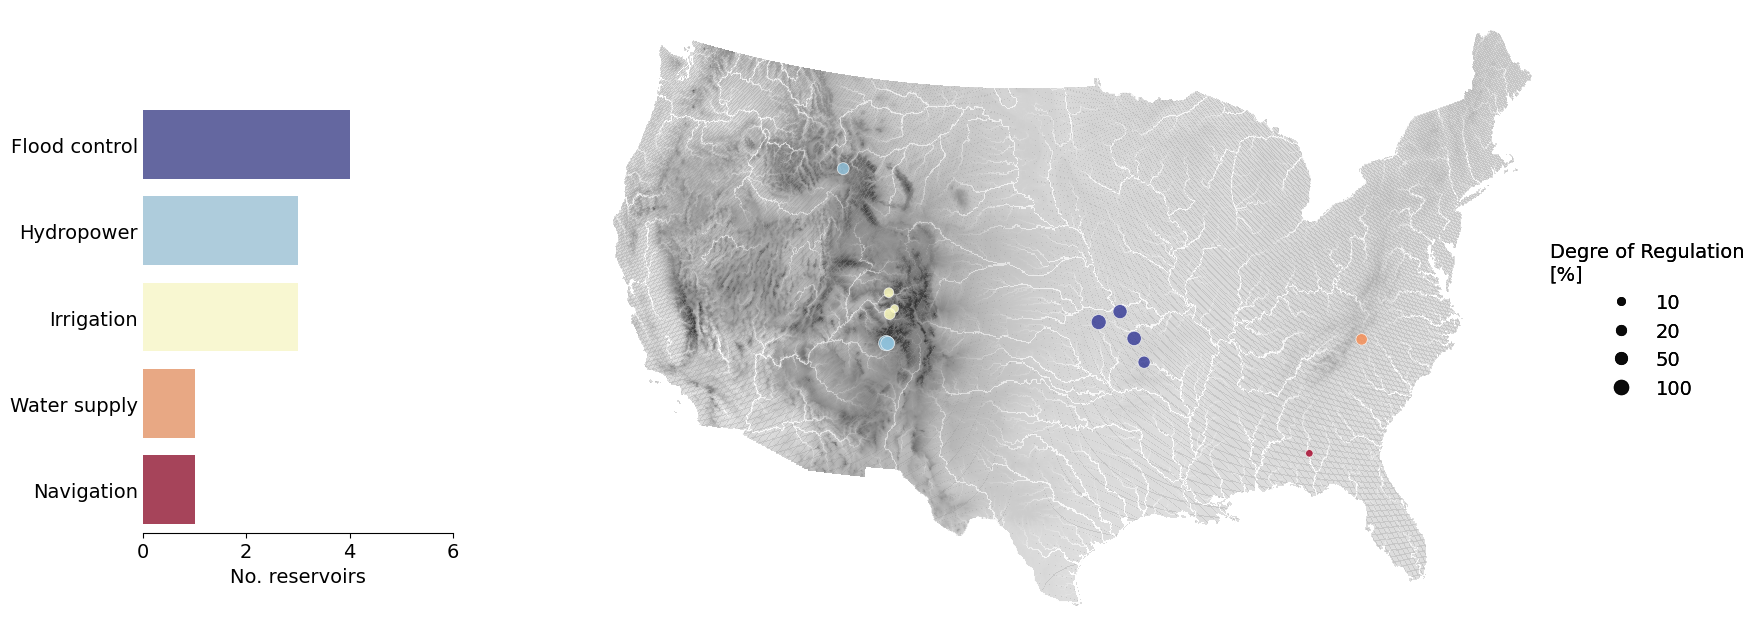

In [11]:
plt.rcParams.update({'font.size': 14})

map_reservoirs_use(
    reservoirs.geometry,
    attributes['MAIN_USE'],
    attributes['DOR_PC'],
    elevation,
    uparea,
    proj='epsg:9311',
    extent=[-120, -75, 25, 50],
    cmap='RdYlBu_r',
    xlim=(0, 6),
    # save=PATH_PLOTS / f'map_reservoirs_use_epsg{epsg}.pdf'
)

### Performance

#### Compare simulations

##### GWW calibration

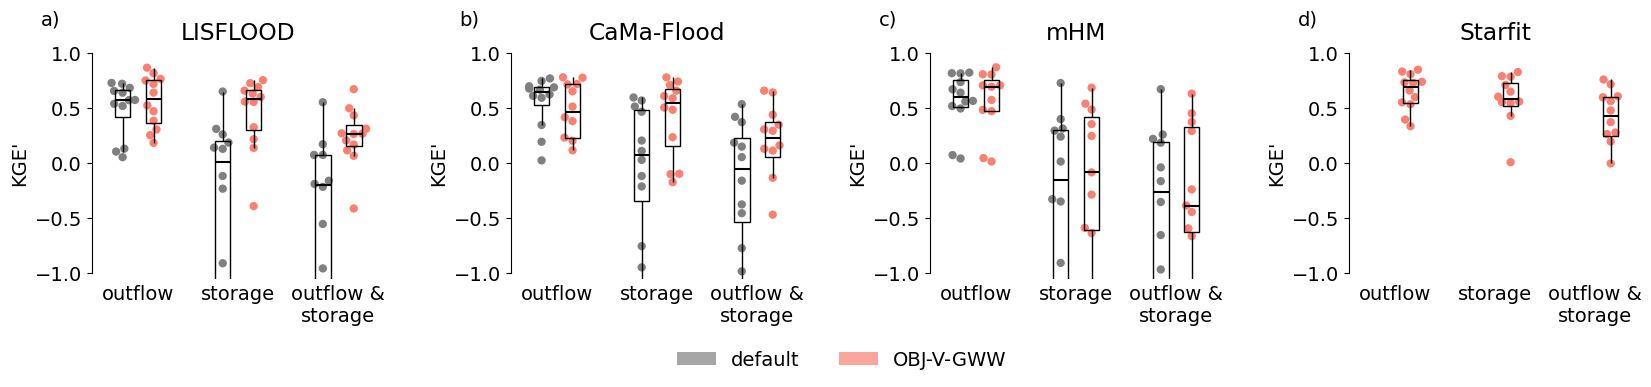

In [ ]:
plt.rcParams.update({'font.size': 14})

# compare runs
swarmplot_comparison(
    performance_gww.sel(model=['LISFLOOD', 'CaMa-Flood', 'mHM', 'Starfit'], run=['default', 'OBJ-V-GWW']),
    ax_dim='model',
    col_dim='run',
    kind='swarm',
    size=6,
    ylabel="KGE'",
    width_ratio=1.2,
    # save=PATH_RESULTS / f'swarmplots_compare_variables_gww.pdf'
)

In [24]:
# model performance with default parameters
gww_default = performance_gww.sel(run='default', metric='KGE').median('ID').to_dataframe()[['storage', 'outflow']]

gww_default

,storage,outflow
model,,
LISFLOOD,0.007315,0.574156
CaMa-Flood,0.071157,0.647609
mHM,-0.155861,0.604056
Starfit,NaN,NaN


In [25]:
# model performance after GWW calibration
gww_calibrated = performance_gww.sel(run='OBJ-V-GWW', metric='KGE').median('ID').to_dataframe()[['storage', 'outflow']]

gww_calibrated

,storage,outflow
model,,
LISFLOOD,0.581471,0.583849
CaMa-Flood,0.548762,0.466656
mHM,-0.083273,0.695392
Starfit,0.582915,0.695299


In [26]:
# increase in performance after calibration
gww_calibrated - gww_default

,storage,outflow
model,,
LISFLOOD,0.574156,0.009693
CaMa-Flood,0.477605,-0.180953
mHM,0.072588,0.091336
Starfit,NaN,NaN


##### In situ data calibration

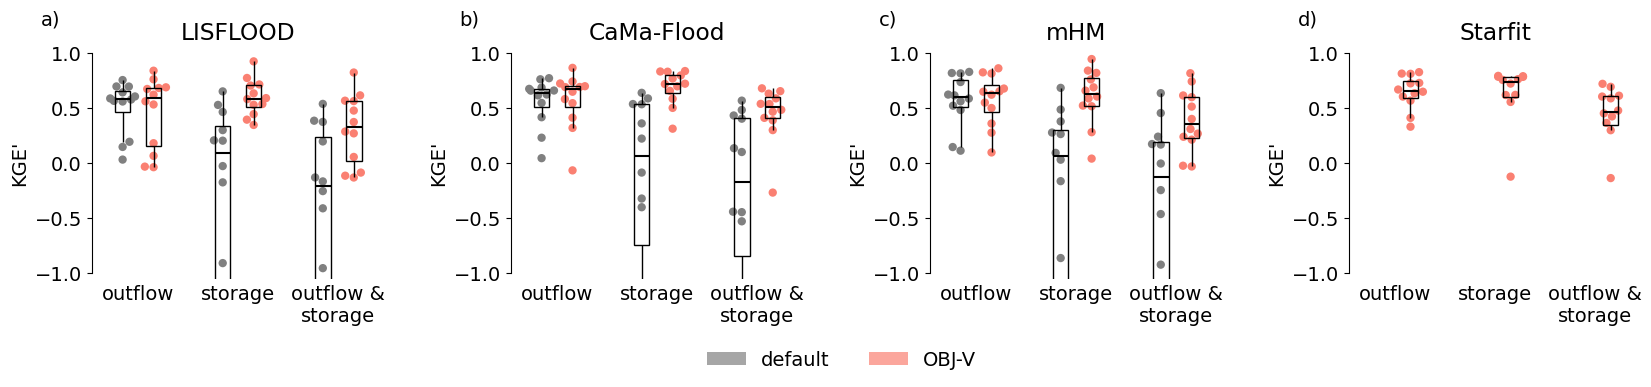

In [ ]:
plt.rcParams.update({'font.size': 14})

# compare runs
swarmplot_comparison(
    performance_insitu.sel(model=['LISFLOOD', 'CaMa-Flood', 'mHM', 'Starfit'], run=['default', 'OBJ-V']),
    ax_dim='model',
    col_dim='run',
    kind='swarm',
    size=6,
    ylabel="KGE'",
    width_ratio=1.2,
    # save=PATH_RESULTS / f'swarmplots_compare_variables_insitu.pdf'
)

In [27]:
# model performance with default parameters
insitu_default = performance_insitu.sel(run='default', metric='KGE').median('ID').to_dataframe()[['storage', 'outflow']]

insitu_default

,storage,outflow
model,,
LISFLOOD,0.0895,0.5840
CaMa-Flood,0.0695,0.6425
mHM,0.0630,0.6025
Starfit,NaN,NaN


In [28]:
# model_performance after calibration with in situ data
insitu_calibrated = performance_insitu.sel(run='OBJ-V', metric='KGE').median('ID').to_dataframe()[['storage', 'outflow']]

insitu_calibrated

,storage,outflow
model,,
LISFLOOD,0.5875,0.5930
CaMa-Flood,0.7215,0.6710
mHM,0.6330,0.6365
Starfit,0.7405,0.6600


#### Compare models

##### GWW calibration

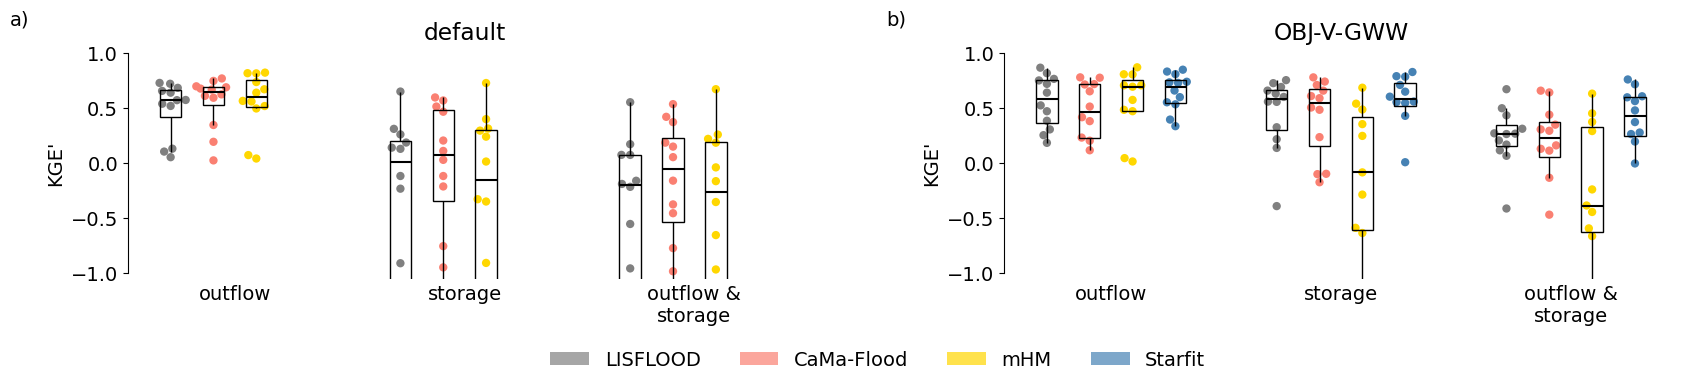

In [18]:
plt.rcParams.update({'font.size': 14})

# compare models
swarmplot_comparison(
    performance_gww.sel(model=['LISFLOOD', 'CaMa-Flood', 'mHM', 'Starfit'], run=['default', 'OBJ-V-GWW']),
    ax_dim='run',
    col_dim='model',
    kind='swarm',
    size=6,
    ylabel="KGE'",
    # wspace=.2,
    width_ratio=.8,
    # save=PATH_RESULTS / f'swarmplots_compare_models_gww.pdf'
)

##### In situ data calibration

In [ ]:
plt.rcParams.update({'font.size': 14})

# compare models
swarmplot_comparison(
    performance_insitu.sel(model=['LISFLOOD', 'CaMa-Flood', 'mHM'], run=['default', 'OBJ-V']),
    ax_dim='run',
    col_dim='model',
    kind='swarm',
    size=6,
    ylabel="KGE'",
    # wspace=.2,
    width_ratio=.8,
    # save=PATH_RESULTS / f'swarmplots_compare_models_gww.pdf'
)